In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# load data
cal_df = pd.read_csv('data/jpm_calibration.csv')
val_df = pd.read_csv('data/jpm_validation.csv')

cal_size = cal_df.iloc[:, 0].values
cal_impmax = cal_df.iloc[:, 1].values

val_size = val_df.iloc[:, 0].values
val_impmax = val_df.iloc[:, 1].values

In [2]:
# fitting power law parameters
def power_law(x, A, b):
    return A * (x ** b)

# fit curve
params, _ = curve_fit(power_law, cal_impmax, cal_size)
A, b = params
print(f'A = {A:.4f}')
print(f'b = {b:.4f}')

# predicted calibration values
cal_predicted = power_law(cal_impmax, A, b)
r2 = r2_score(cal_size, cal_predicted)
print(f'R² = {r2:.4f}')

A = 21.9187
b = 0.5631
R² = 0.6606


In [3]:
# calculate predicted validation values

val_predicted = power_law(val_impmax, A, b)
rmse = np.sqrt(mean_squared_error(val_size, val_predicted))
mae = mean_absolute_error(val_size, val_predicted)

print(f'RMSE = {rmse:.2f} mm')
print(f'MAE  = {mae:.2f} mm')

RMSE = 22.64 mm
MAE  = 16.50 mm


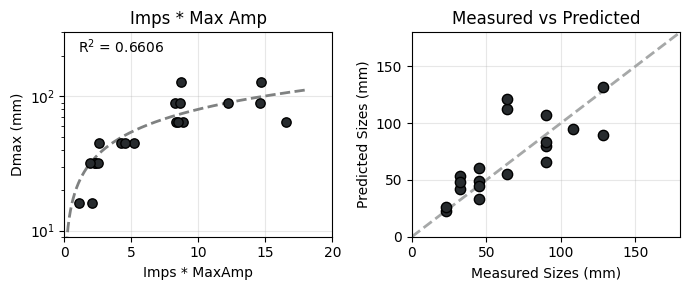

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
# plot the grid behind the data points
# calibration curve
ax = axes[0]
ax.scatter(cal_impmax, cal_size, s=45, color="#272B2E", edgecolor="#000000", zorder=3)
x_line = np.linspace(0.01, 18, 400)
y_line = power_law(x_line, A, b)
ax.plot(x_line, y_line, linestyle='--', linewidth=2, color="#7f8181") # fitted curve
ax.set_yscale('log')
ax.set_xlim(0, 20)
ax.set_ylim(9, 300)
ax.set_xlabel('Imps * MaxAmp', fontsize=10)
ax.set_ylabel('Dmax (mm)', fontsize=10)
ax.set_title('Imps * Max Amp', fontsize=12)
ax.grid(True, which='major', alpha=0.3)
ax.text(0.05, 0.9, rf'R$^2$ = {r2:.4f}', transform=ax.transAxes, fontsize=10)

# validation plot
ax = axes[1]
ax.scatter(val_size, val_predicted, s=55, color="#272B2E", edgecolor="#000000", zorder=3)
ax.plot([0, 200], [0, 200], linestyle='--', linewidth=2, color="#a6a8a8") # 1:1 line
ax.set_xlim(0, 180)
ax.set_ylim(0, 180)
ax.set_xlabel('Measured Sizes (mm)', fontsize=10)
ax.set_ylabel('Predicted Sizes (mm)', fontsize=10)
ax.set_title('Measured vs Predicted', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('jpm_calibration_validation.png', dpi=400)
plt.show()